In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Heart_CSV = pd.read_csv("disease_prediction.csv")
Heart_CSV.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [23]:
Heart_CSV.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   str    
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   str    
 10  alcohol_consumption  1000 non-null   str    
 11  physical_activity    1000 non-null   str    
 12  family_history       1000 non-null   str    
 13  disease              1000 non-null   str    
dtypes: float64(1), int64(7), str(6)
memory usage: 109.5 KB


In [24]:
Heart_CSV = pd.get_dummies(
    Heart_CSV,
    columns=[
        'gender',
        'smoking',
        'disease',
        'alcohol_consumption',
        'physical_activity',
        'family_history'
    ],
    drop_first=True,
    dtype=int
)


X = Heart_CSV.drop(columns=['patient_id', 'disease_Yes'])
y = Heart_CSV['disease_Yes']

Heart_CSV.head()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,gender_Male,smoking_Yes,disease_Yes,alcohol_consumption_Yes,physical_activity_Low,physical_activity_Medium,family_history_Yes
0,1,32,101,235,152,79,28.5,73,1,0,1,1,1,0,1
1,2,31,124,191,134,77,33.9,71,1,0,1,1,1,0,1
2,3,45,57,141,114,71,27.2,79,1,1,0,1,1,0,0
3,4,75,69,268,120,82,21.5,61,0,1,1,1,0,1,0
4,5,53,107,163,131,75,23.3,73,1,1,1,0,1,0,1


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter Grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

# Create Grid Search
grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train Grid Search
grid.fit(X_train, y_train)

# Best Results
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.93125


In [27]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred)) 
print("\nConfusion Matrix") 
print(confusion_matrix(y_test, y_pred)) 
print("\nClassification Report") 
print(classification_report(y_test, y_pred))

Accuracy: 0.945

Confusion Matrix
[[96  9]
 [ 2 93]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.91      0.95       105
           1       0.91      0.98      0.94        95

    accuracy                           0.94       200
   macro avg       0.95      0.95      0.94       200
weighted avg       0.95      0.94      0.95       200



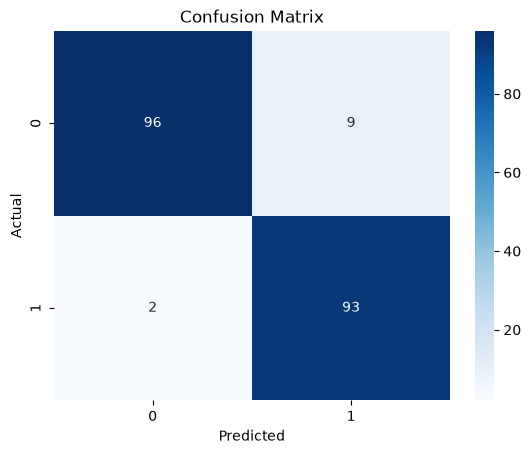

In [30]:
cm = confusion_matrix(y_test, y_pred) 

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') 

plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.title("Confusion Matrix") 
plt.show()